<a href="https://colab.research.google.com/github/elangbijak4/multi-agent-AI/blob/main/Hyperparameter_Tuning2_Agent_dengan_banyak_Otak_terintegrasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== META-AGENT: Hyperparameter Optimization ===
Trial 01 | Avg CV Score: 0.8315
Trial 02 | Avg CV Score: 0.8333
Trial 03 | Avg CV Score: 0.8387
Trial 04 | Avg CV Score: 0.8277
Trial 05 | Avg CV Score: 0.8327
Trial 06 | Avg CV Score: 0.8339
Trial 07 | Avg CV Score: 0.8310
Trial 08 | Avg CV Score: 0.8235
Trial 09 | Avg CV Score: 0.8369
Trial 10 | Avg CV Score: 0.8289
Trial 11 | Avg CV Score: 0.8315
Trial 12 | Avg CV Score: 0.8375
Trial 13 | Avg CV Score: 0.8265
Trial 14 | Avg CV Score: 0.8348
Trial 15 | Avg CV Score: 0.8280

Best Hyperparameter Strategy Found:
{'tree_depth': np.int64(8), 'linear_C': np.float64(1.0), 'svm_C': np.float64(5.0), 'svm_gamma': np.str_('scale')}

=== AGENT ACTIVATION WITH OPTIMIZED BRAINS ===

Meta-Agent selects integration mode: Single Brain


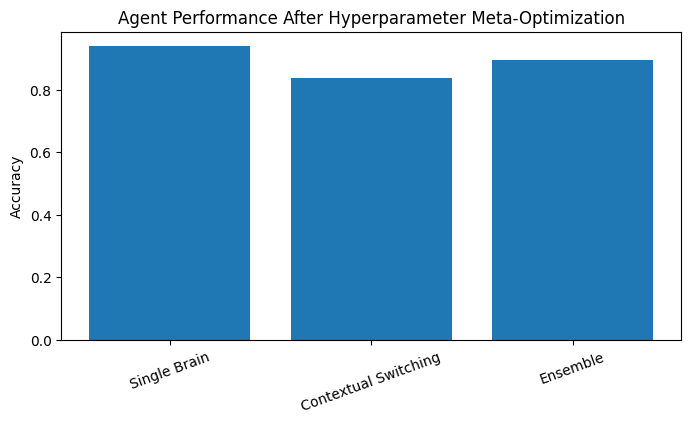

In [1]:
# ============================================================
# UNIFIED INTELLIGENT AGENT
# Brain Optimization + Hyperparameter Meta-Optimization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ------------------------------------------------------------
# 1. ENVIRONMENT
# ------------------------------------------------------------
X, y = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=6,
    n_redundant=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ------------------------------------------------------------
# 2. BRAIN FACTORY (with hyperparameter slots)
# ------------------------------------------------------------
def brain_factory(hp=None):
    """
    hp = hyperparameter dictionary chosen by meta-agent
    """
    if hp is None:
        hp = {}

    return {
        "Tree": DecisionTreeClassifier(
            max_depth=hp.get("tree_depth", 5)
        ),
        "Bayes": GaussianNB(),  # no major hyperparameter
        "Linear": LogisticRegression(
            C=hp.get("linear_C", 1.0),
            max_iter=1000
        ),
        "SVM": SVC(
            C=hp.get("svm_C", 1.0),
            gamma=hp.get("svm_gamma", "scale"),
            probability=True
        )
    }

# ------------------------------------------------------------
# 3. AGENT DEFINITION
# ------------------------------------------------------------
class IntelligentAgent:

    def __init__(self):
        self.mode_performance = {}
        self.hp_memory = []

    # ----------------------
    # Core perception-action loop
    # ----------------------
    def perceive(self, X):
        return X

    def optimize_brains(self, brains, X, y):
        for brain in brains.values():
            brain.fit(X, y)

    def act(self, brain, X):
        return brain.predict(X)

    def evaluate(self, y_pred, y_true):
        return accuracy_score(y_true, y_pred)

    # ----------------------
    # MODE 1: Single Brain
    # ----------------------
    def mode_single_brain(self, brains):
        scores = {}
        for name, brain in brains.items():
            y_pred = self.act(brain, X_test)
            scores[name] = self.evaluate(y_pred, y_test)

        best = max(scores, key=scores.get)
        self.mode_performance["Single Brain"] = scores[best]

    # ----------------------
    # MODE 2: Contextual Switching
    # ----------------------
    def mode_contextual(self, brains):
        preds = []
        for x in X_test:
            if np.mean(x) > 0:
                preds.append(brains["Tree"].predict(x.reshape(1,-1))[0])
            else:
                preds.append(brains["Linear"].predict(x.reshape(1,-1))[0])

        acc = self.evaluate(np.array(preds), y_test)
        self.mode_performance["Contextual Switching"] = acc

    # ----------------------
    # MODE 3: Ensemble
    # ----------------------
    def mode_ensemble(self, brains):
        prob_sum = np.zeros(len(X_test))
        for brain in brains.values():
            if hasattr(brain, "predict_proba"):
                prob_sum += brain.predict_proba(X_test)[:,1]
            else:
                prob_sum += brain.predict(X_test)

        preds = (prob_sum / len(brains)) > 0.5
        acc = self.evaluate(preds.astype(int), y_test)
        self.mode_performance["Ensemble"] = acc

    # ----------------------
    # MODE 4: Meta-Agent Mode Selection
    # ----------------------
    def meta_mode_selection(self):
        return max(self.mode_performance, key=self.mode_performance.get)

    # ------------------------------------------------
    # META-AGENT: Hyperparameter Tuning
    # ------------------------------------------------
    def hyperparameter_tuning(self, trials=12):
        """
        Meta-agent explores learning strategies
        """
        search_space = {
            "tree_depth": [3, 5, 8],
            "linear_C": [0.1, 1.0, 10],
            "svm_C": [0.5, 1.0, 5],
            "svm_gamma": ["scale", "auto"]
        }

        best_score = -np.inf
        best_hp = None

        for t in range(trials):
            hp = {
                key: np.random.choice(values)
                for key, values in search_space.items()
            }

            brains = brain_factory(hp)
            self.optimize_brains(brains, X_train, y_train)

            scores = []
            for brain in brains.values():
                cv = cross_val_score(brain, X_train, y_train, cv=3)
                scores.append(cv.mean())

            avg_score = np.mean(scores)
            self.hp_memory.append((hp, avg_score))

            if avg_score > best_score:
                best_score = avg_score
                best_hp = hp

            print(f"Trial {t+1:02d} | Avg CV Score: {avg_score:.4f}")

        print("\nBest Hyperparameter Strategy Found:")
        print(best_hp)
        return best_hp

# ------------------------------------------------------------
# 4. AGENT LIFE CYCLE
# ------------------------------------------------------------
agent = IntelligentAgent()

print("\n=== META-AGENT: Hyperparameter Optimization ===")
best_hp = agent.hyperparameter_tuning(trials=15)

print("\n=== AGENT ACTIVATION WITH OPTIMIZED BRAINS ===")
brains = brain_factory(best_hp)
agent.optimize_brains(brains, X_train, y_train)

agent.mode_single_brain(brains)
agent.mode_contextual(brains)
agent.mode_ensemble(brains)

best_mode = agent.meta_mode_selection()
print(f"\nMeta-Agent selects integration mode: {best_mode}")

# ------------------------------------------------------------
# 5. VISUAL SUMMARY
# ------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.bar(agent.mode_performance.keys(), agent.mode_performance.values())
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Agent Performance After Hyperparameter Meta-Optimization")
plt.show()